In [3]:
#Load and inspect
import pandas as pd


df = pd.read_csv('/content/zomato.csv',engine='python', on_bad_lines='skip')

print(df.shape)
df.info()
df.head()

(11684, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11684 entries, 0 to 11683
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          11684 non-null  object
 1   address                      11684 non-null  object
 2   name                         11684 non-null  object
 3   online_order                 11684 non-null  object
 4   book_table                   11684 non-null  object
 5   rate                         10001 non-null  object
 6   votes                        11684 non-null  int64 
 7   phone                        11457 non-null  object
 8   location                     11682 non-null  object
 9   rest_type                    11629 non-null  object
 10  dish_liked                   5164 non-null   object
 11  cuisines                     11674 non-null  object
 12  approx_cost(for two people)  11654 non-null  object
 13  reviews_list       

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
df.isnull().sum().sort_values(ascending=False)

,0
dish_liked,6520
rate,1683
phone,227
rest_type,55
approx_cost(for two people),30
cuisines,10
location,2
url,0
address,0
votes,0


In [5]:
#Clean and transform
# Drop columns not useful for analysis
df = df.drop(columns=['url', 'address', 'phone', 'reviews_list', 'menu_item', 'dish_liked'], errors='ignore')

# Drop exact duplicates
df = df.drop_duplicates()

# Clean the 'rate' column (comes as "4.1/5", "NEW", "-")
def clean_rate(x):
    if isinstance(x, str) and '/' in x:
        return float(x.split('/')[0])
    return None

df['rating'] = df['rate'].apply(clean_rate)
df = df.drop(columns=['rate'])

# Clean cost column (comes as "1,200" with commas)
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str).str.replace(',', '', regex=False)
)
df['cost_for_two'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')
df = df.drop(columns=['approx_cost(for two people)'])

# Standardize text columns
df['location'] = df['location'].str.strip()
df['rest_type'] = df['rest_type'].str.strip()

# Drop rows with no rating or no cost (can't analyze what we don't have)
df = df.dropna(subset=['rating', 'cost_for_two'])

df[['name','location','rating','cost_for_two','online_order','book_table']].head()

,name,location,rating,cost_for_two,online_order,book_table
0,Jalsa,Banashankari,4.1,800.0,Yes,Yes
1,Spice Elephant,Banashankari,4.1,800.0,Yes,No
2,San Churro Cafe,Banashankari,3.8,800.0,Yes,No
3,Addhuri Udupi Bhojana,Banashankari,3.7,300.0,No,No
4,Grand Village,Basavanagudi,3.8,600.0,No,No


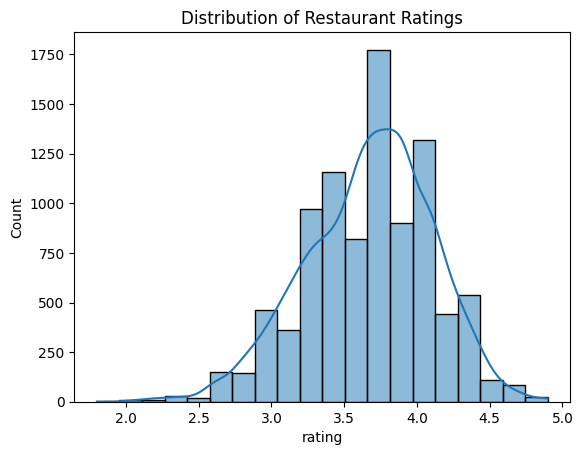

In [6]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

# Rating distribution
sns.histplot(df['rating'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.show()

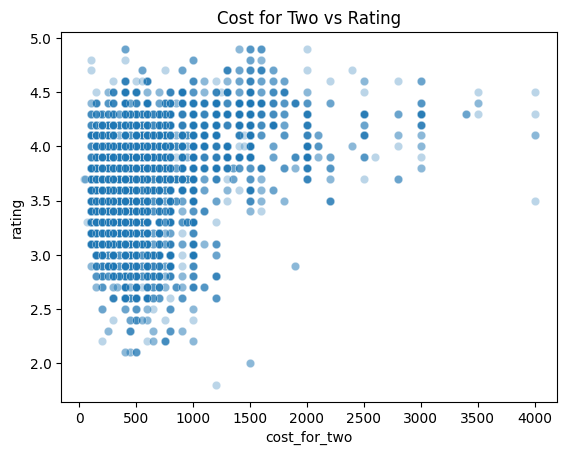

In [7]:
# Cost vs rating relationship
sns.scatterplot(data=df, x='cost_for_two', y='rating', alpha=0.3)
plt.title('Cost for Two vs Rating')
plt.show()

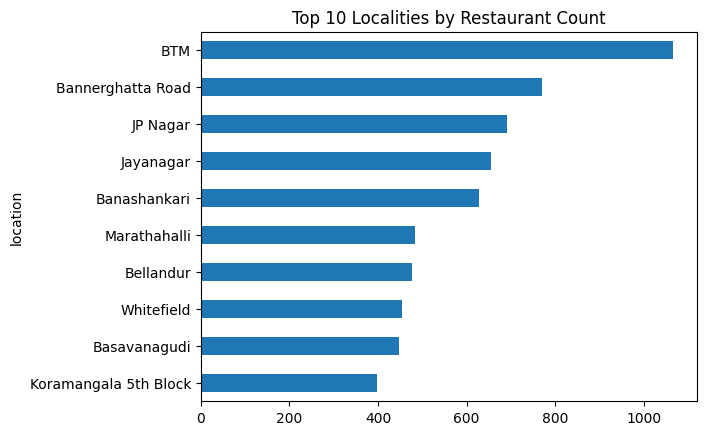

In [8]:
# Top 10 localities by number of restaurants
df['location'].value_counts().head(10).plot(kind='barh', title='Top 10 Localities by Restaurant Count')
plt.gca().invert_yaxis()
plt.show()

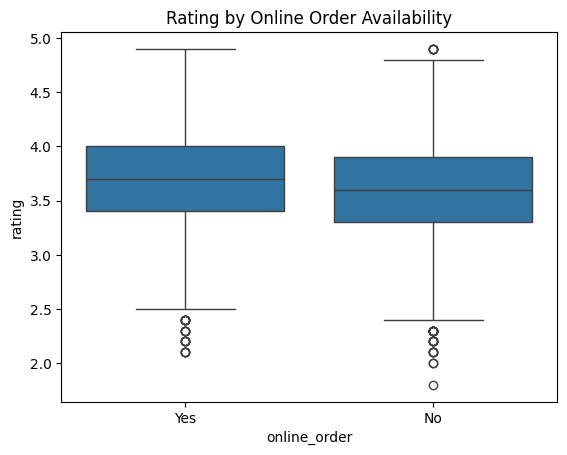

In [9]:
# Does online ordering correlate with higher ratings?
sns.boxplot(data=df, x='online_order', y='rating')
plt.title('Rating by Online Order Availability')
plt.show()

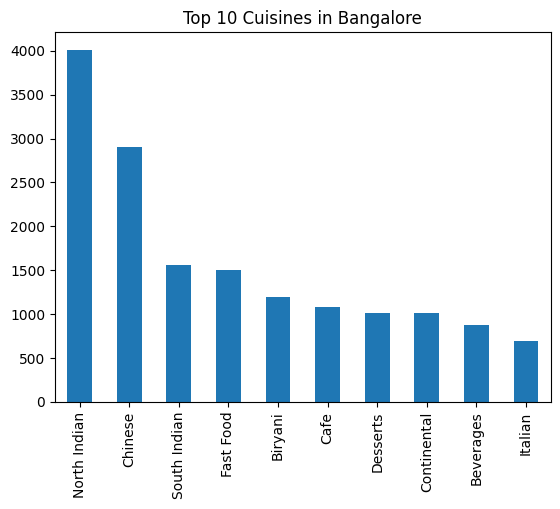

In [10]:
# Most common cuisines (cuisines column has comma-separated values)
from collections import Counter
cuisine_counts = Counter()
df['cuisines'].dropna().str.split(', ').apply(cuisine_counts.update)
top_cuisines = pd.Series(dict(cuisine_counts)).sort_values(ascending=False).head(10)
top_cuisines.plot(kind='bar', title='Top 10 Cuisines in Bangalore')
plt.show()

In [11]:
#SQL analysis with window functions (SQLite, in-memory)
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('restaurants', conn, index=False, if_exists='replace')

query = """
SELECT name, location, rating, cost_for_two,
       RANK() OVER (PARTITION BY location ORDER BY rating DESC) AS rank_in_location
FROM restaurants
WHERE location IN (
    SELECT location FROM restaurants GROUP BY location HAVING COUNT(*) > 50
)
"""
result = pd.read_sql(query, conn)
result[result['rank_in_location'] <= 3].head(20)  # top 3 rated restaurants per major locality

,name,location,rating,cost_for_two,rank_in_location
0,AB's - Absolute Barbecues,BTM,4.9,1600.0,1
1,AB's - Absolute Barbecues,BTM,4.9,1600.0,1
2,eat.fit,BTM,4.5,500.0,3
3,XO Belgian Waffle,BTM,4.5,400.0,3
4,eat.fit,BTM,4.5,500.0,3
5,Pin Me Down,BTM,4.5,800.0,3
6,Mudpipe Cafe,BTM,4.5,900.0,3
7,Mudpipe Cafe,BTM,4.5,900.0,3
8,eat.fit,BTM,4.5,500.0,3
9,XO Belgian Waffle,BTM,4.5,400.0,3


In [13]:
#Export cleaned data
from google.colab import files
df.to_csv('zomato_cleaned.csv', index=False)
files.download('zomato_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>